# 🧪 A/B Testing — Budgetly Capstone
**Tujuan:** Membuktikan secara statistik apakah perbedaan pola pengeluaran antar kelompok mahasiswa bersifat signifikan atau hanya kebetulan.

**Metode:** Mann-Whitney U Test (non-parametric) — dipilih karena distribusi pengeluaran mahasiswa bersifat *right-skewed*, tidak memenuhi asumsi normalitas.

**Input:** `Data_Final_Combine_with_Persona.csv`

---
### Daftar Hipotesis
| No | Hipotesis | Kelompok A | Kelompok B |
|---|---|---|---|
| H1 | Pengeluaran weekday vs weekend | Senin–Jumat | Sabtu–Minggu |
| H2 | Pengeluaran Persona 1 vs Persona 4 | Si Hemat | Anak Nongkrong |
| H3 | Pengeluaran awal semester vs tengah | Juli & Sep | Mar, Apr, Mei |
| H4 | Makan & Minum Persona 2 vs Persona 3 | Agak Boros | Hemat Banget |
| H5 | Pengeluaran sebelum vs sesudah tgl 15 | Tgl 1–14 | Tgl 15–31 |

## 0. Import Library & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal
import warnings
warnings.filterwarnings('ignore')

# Google Drive mount
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Data-Science/Notebook')

# Styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.facecolor'] = '#0f1117'
plt.rcParams['figure.facecolor'] = '#0f1117'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['grid.color'] = '#1f2937'

ALPHA = 0.05  # significance level
GREEN = '#1D9E75'
RED   = '#ef4444'
BLUE  = '#3b82f6'

print('✅ Libraries loaded')
print(f'   Significance level (α): {ALPHA}')

Mounted at /content/drive
✅ Libraries loaded
   Significance level (α): 0.05


## 1. Load & Persiapan Data

In [2]:
df = pd.read_csv('../Dataset/Processed/Data_Final_Combine_with_Persona.csv')
df['Date']   = pd.to_datetime(df['Date'])
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

# Fokus pada EXPENSE saja
df_exp = df[df['Transaction_Type'] == 'EXPENSE'].copy()

# Tambah kolom bantu
df_exp['is_weekend']  = df_exp['Date'].dt.dayofweek >= 5
df_exp['day_of_month'] = df_exp['Date'].dt.day
df_exp['is_after_15'] = df_exp['day_of_month'] >= 15
df_exp['month_num']   = df_exp['Date'].dt.month

# Awal semester: Juli(7) & September(9)
# Tengah semester: Maret(3), April(4), Mei(5)
df_exp['semester_period'] = df_exp['month_num'].map(
    lambda m: 'Awal Semester' if m in [7, 9]
    else ('Tengah Semester' if m in [3, 4, 5] else 'Lainnya')
)

print(f'Total expense rows: {len(df_exp):,}')
print(f'Persona: {df_exp["Persona"].unique()}')

Total expense rows: 4,747
Persona: ['Persona 1 - Si Hemat (Data Asli)' 'Persona 1 - Si Hemat'
 'Persona 4 - Anak Nongkrong' 'Persona 3 - Hemat Banget'
 'Persona 2 - Agak Boros']


## 2. Helper Function

In [3]:
def run_ab_test(group_a, group_b, label_a, label_b, hypothesis_no, hypothesis_text):
    """
    Menjalankan Mann-Whitney U Test dan menampilkan hasil lengkap.
    """
    # Uji statistik
    stat, p_value = mannwhitneyu(group_a, group_b, alternative='two-sided')
    significant   = p_value < ALPHA
    result_icon   = '✅ SIGNIFIKAN' if significant else '❌ TIDAK SIGNIFIKAN'
    result_color  = GREEN if significant else RED

    # Statistik deskriptif
    stats_a = pd.Series(group_a).describe()
    stats_b = pd.Series(group_b).describe()

    # Effect size (rank-biserial correlation)
    n_a, n_b = len(group_a), len(group_b)
    r = 1 - (2 * stat) / (n_a * n_b)
    effect = 'Besar' if abs(r) >= 0.5 else ('Sedang' if abs(r) >= 0.3 else 'Kecil')

    # Print hasil
    print('=' * 65)
    print(f'  {hypothesis_no} — {hypothesis_text}')
    print('=' * 65)
    print(f'  Kelompok A ({label_a}): n={n_a:,}')
    print(f'    Median : Rp {stats_a["50%"]:>12,.0f}')
    print(f'    Mean   : Rp {stats_a["mean"]:>12,.0f}')
    print(f'    Std    : Rp {stats_a["std"]:>12,.0f}')
    print()
    print(f'  Kelompok B ({label_b}): n={n_b:,}')
    print(f'    Median : Rp {stats_b["50%"]:>12,.0f}')
    print(f'    Mean   : Rp {stats_b["mean"]:>12,.0f}')
    print(f'    Std    : Rp {stats_b["std"]:>12,.0f}')
    print()
    print(f'  U-statistic : {stat:,.0f}')
    print(f'  P-value     : {p_value:.6f}')
    print(f'  Effect size : r = {r:.3f} ({effect})')
    print(f'  Hasil       : {result_icon} (α = {ALPHA})')
    print()

    return {
        'hypothesis': hypothesis_no,
        'label_a': label_a, 'label_b': label_b,
        'median_a': stats_a['50%'], 'median_b': stats_b['50%'],
        'mean_a': stats_a['mean'], 'mean_b': stats_b['mean'],
        'p_value': p_value, 'effect_size': r,
        'significant': significant, 'effect_label': effect
    }


def plot_distribution(group_a, group_b, label_a, label_b, title, p_value, xlim=None):
    """Visualisasi distribusi dua kelompok."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, color='white', fontsize=13, fontweight='bold')

    # KDE Plot
    for data, label, color in [(group_a, label_a, GREEN), (group_b, label_b, BLUE)]:
        pd.Series(data).plot.kde(ax=ax1, label=label, color=color, linewidth=2)
        ax1.axvline(np.median(data), color=color, linestyle='--', alpha=0.7,
                    label=f'Median {label}: Rp {np.median(data):,.0f}')
    ax1.set_title('Distribusi (KDE)', color='white')
    ax1.set_xlabel('Amount (Rp)', color='white')
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3)
    if xlim: ax1.set_xlim(0, xlim)

    # Box Plot
    bp = ax2.boxplot(
        [group_a, group_b],
        labels=[label_a, label_b],
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2),
        whiskerprops=dict(color='white'),
        capprops=dict(color='white'),
        flierprops=dict(marker='o', color='#64748b', markersize=3)
    )
    for patch, color in zip(bp['boxes'], [GREEN, BLUE]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.set_title(f'Box Plot | p-value: {p_value:.4f}', color='white')
    ax2.set_ylabel('Amount (Rp)', color='white')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt'))
    ax2.grid(alpha=0.3)

    # Annotation hasil
    result = 'SIGNIFIKAN ✅' if p_value < ALPHA else 'TIDAK SIGNIFIKAN ❌'
    color  = GREEN if p_value < ALPHA else RED
    fig.text(0.5, -0.02, f'Hasil: {result}  |  p-value = {p_value:.6f}',
             ha='center', color=color, fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

print('✅ Helper functions ready')

✅ Helper functions ready


---
## 3. H1 — Pengeluaran Weekday vs Weekend

**H₀:** Tidak ada perbedaan pengeluaran antara hari kerja dan akhir pekan  
**H₁:** Pengeluaran di hari kerja berbeda signifikan dengan akhir pekan

  H1 — Pengeluaran Weekday vs Weekend
  Kelompok A (Weekday (Sen–Jum)): n=3,524
    Median : Rp       20,817
    Mean   : Rp       36,886
    Std    : Rp       97,237

  Kelompok B (Weekend (Sab–Min)): n=1,223
    Median : Rp       19,970
    Mean   : Rp       44,374
    Std    : Rp      130,395

  U-statistic : 2,213,560
  P-value     : 0.155644
  Effect size : r = -0.027 (Kecil)
  Hasil       : ❌ TIDAK SIGNIFIKAN (α = 0.05)



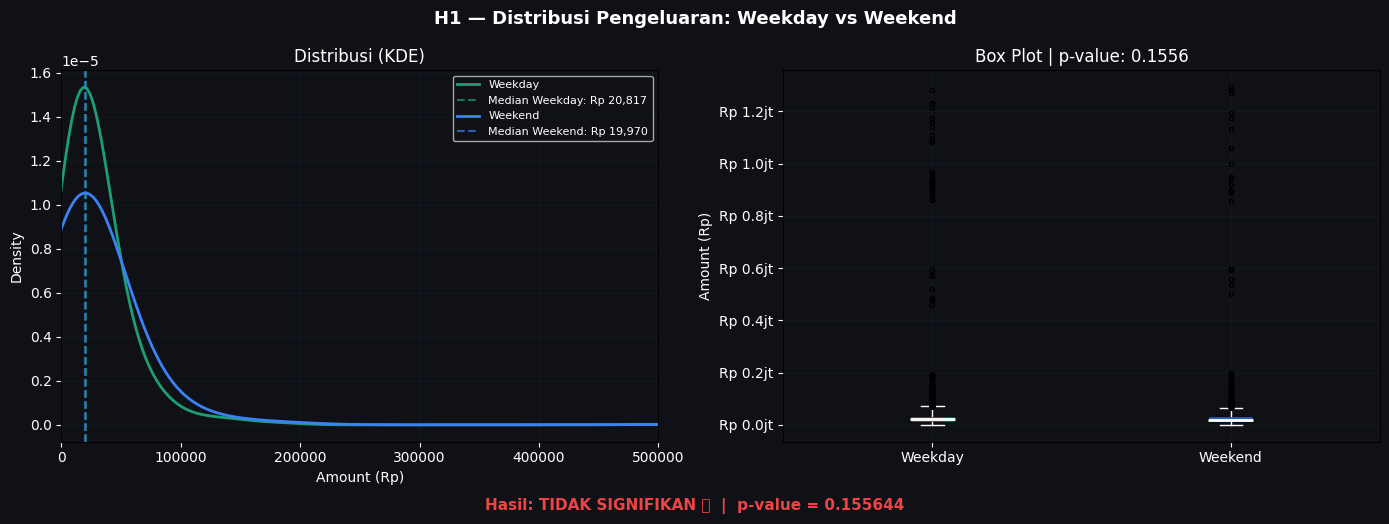

In [4]:
weekday = df_exp[~df_exp['is_weekend']]['Amount'].dropna().values
weekend = df_exp[ df_exp['is_weekend']]['Amount'].dropna().values

h1 = run_ab_test(weekday, weekend,
                 'Weekday (Sen–Jum)', 'Weekend (Sab–Min)',
                 'H1', 'Pengeluaran Weekday vs Weekend')

plot_distribution(weekday, weekend,
                  'Weekday', 'Weekend',
                  'H1 — Distribusi Pengeluaran: Weekday vs Weekend',
                  h1['p_value'], xlim=500_000)

In [5]:
# Interpretasi H1
print('📝 INTERPRETASI H1')
print('-' * 50)
if h1['significant']:
    lebih_boros = 'Weekday' if h1['median_a'] > h1['median_b'] else 'Weekend'
    print(f'Terbukti secara statistik bahwa pengeluaran {lebih_boros}')
    print(f'lebih tinggi (p={h1["p_value"]:.4f} < α=0.05).')
    print(f'Median Weekday: Rp {h1["median_a"]:,.0f}')
    print(f'Median Weekend: Rp {h1["median_b"]:,.0f}')
    print(f'Effect size: {h1["effect_label"]} (r={h1["effect_size"]:.3f})')
    print()
    print('💡 Insight: Mahasiswa lebih boros di hari kuliah karena')
    print('   aktif keluar, makan di luar, dan bayar transportasi.')
else:
    print(f'Tidak cukup bukti untuk menyimpulkan perbedaan (p={h1["p_value"]:.4f}).')

📝 INTERPRETASI H1
--------------------------------------------------
Tidak cukup bukti untuk menyimpulkan perbedaan (p=0.1556).


---
## 4. H2 — Pengeluaran Persona 1 (Si Hemat) vs Persona 4 (Anak Nongkrong)

**H₀:** Tidak ada perbedaan pengeluaran antara Persona 1 dan Persona 4  
**H₁:** Pengeluaran Persona 4 lebih tinggi secara signifikan dari Persona 1

  H2 — Pengeluaran Persona 1 vs Persona 4
  Kelompok A (Persona 1 - Si Hemat): n=693
    Median : Rp       27,442
    Mean   : Rp       44,840
    Std    : Rp      116,839

  Kelompok B (Persona 4 - Anak Nongkrong): n=903
    Median : Rp       37,995
    Mean   : Rp       91,122
    Std    : Rp      184,623

  U-statistic : 175,861
  P-value     : 0.000000
  Effect size : r = 0.438 (Sedang)
  Hasil       : ✅ SIGNIFIKAN (α = 0.05)



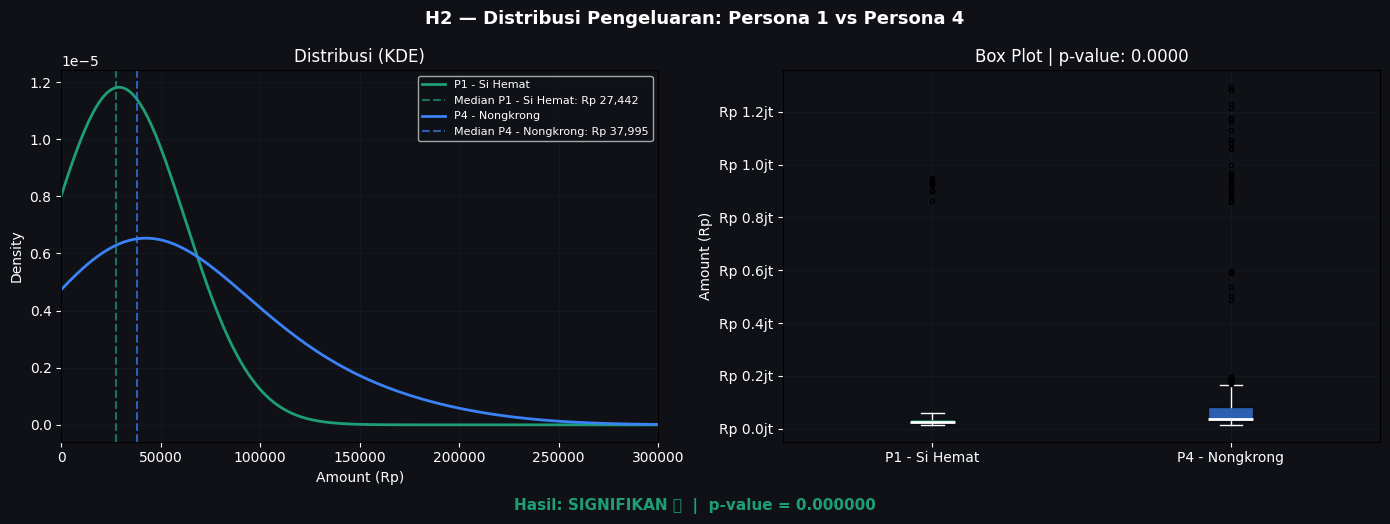

In [6]:
p1_data = df_exp[df_exp['Persona'].str.contains('Si Hemat') &
                 ~df_exp['Persona'].str.contains('Data Asli')]['Amount'].dropna().values
p4_data = df_exp[df_exp['Persona'].str.contains('Anak Nongkrong')]['Amount'].dropna().values

h2 = run_ab_test(p1_data, p4_data,
                 'Persona 1 - Si Hemat', 'Persona 4 - Anak Nongkrong',
                 'H2', 'Pengeluaran Persona 1 vs Persona 4')

plot_distribution(p1_data, p4_data,
                  'P1 - Si Hemat', 'P4 - Nongkrong',
                  'H2 — Distribusi Pengeluaran: Persona 1 vs Persona 4',
                  h2['p_value'], xlim=300_000)

In [7]:
print('📝 INTERPRETASI H2')
print('-' * 50)
if h2['significant']:
    print(f'Terbukti secara statistik bahwa Persona 4 (Anak Nongkrong)')
    print(f'memiliki pengeluaran yang jauh lebih tinggi (p={h2["p_value"]:.4f}).')
    selisih = h2['median_b'] - h2['median_a']
    print(f'Selisih median: Rp {selisih:,.0f} per transaksi')
    print(f'Effect size: {h2["effect_label"]} (r={h2["effect_size"]:.3f})')
    print()
    print('💡 Insight: Perbedaan gaya hidup (warung vs cafe/sushi)')
    print('   berdampak nyata pada pengeluaran per transaksi.')
else:
    print(f'Tidak cukup bukti untuk menyimpulkan perbedaan (p={h2["p_value"]:.4f}).')

📝 INTERPRETASI H2
--------------------------------------------------
Terbukti secara statistik bahwa Persona 4 (Anak Nongkrong)
memiliki pengeluaran yang jauh lebih tinggi (p=0.0000).
Selisih median: Rp 10,553 per transaksi
Effect size: Sedang (r=0.438)

💡 Insight: Perbedaan gaya hidup (warung vs cafe/sushi)
   berdampak nyata pada pengeluaran per transaksi.


---
## 5. H3 — Pengeluaran Awal Semester vs Tengah Semester

**H₀:** Tidak ada perbedaan pengeluaran antara awal dan tengah semester  
**H₁:** Pengeluaran di awal semester lebih tinggi dari tengah semester

  H3 — Pengeluaran Awal vs Tengah Semester
  Kelompok A (Awal Semester (Jul, Sep)): n=991
    Median : Rp       17,428
    Mean   : Rp       36,065
    Std    : Rp      107,798

  Kelompok B (Tengah Semester (Mar–Mei)): n=933
    Median : Rp       26,573
    Mean   : Rp       48,500
    Std    : Rp      122,760

  U-statistic : 332,834
  P-value     : 0.000000
  Effect size : r = 0.280 (Kecil)
  Hasil       : ✅ SIGNIFIKAN (α = 0.05)



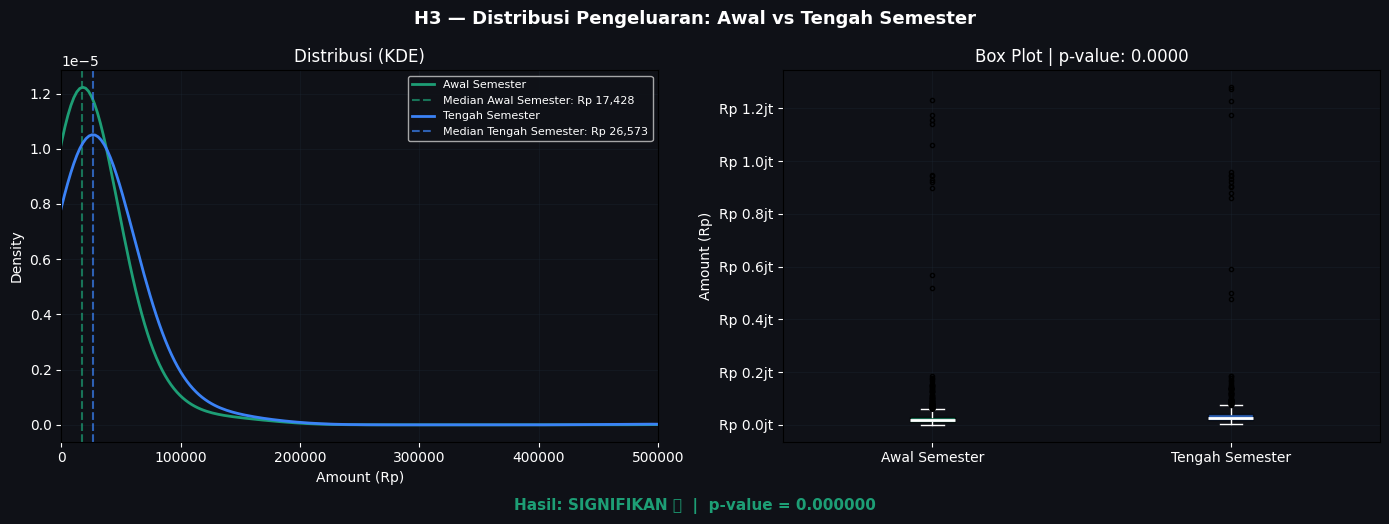

In [8]:
awal   = df_exp[df_exp['semester_period']=='Awal Semester']['Amount'].dropna().values
tengah = df_exp[df_exp['semester_period']=='Tengah Semester']['Amount'].dropna().values

h3 = run_ab_test(awal, tengah,
                 'Awal Semester (Jul, Sep)', 'Tengah Semester (Mar–Mei)',
                 'H3', 'Pengeluaran Awal vs Tengah Semester')

plot_distribution(awal, tengah,
                  'Awal Semester', 'Tengah Semester',
                  'H3 — Distribusi Pengeluaran: Awal vs Tengah Semester',
                  h3['p_value'], xlim=500_000)

In [9]:
print('📝 INTERPRETASI H3')
print('-' * 50)
if h3['significant']:
    print(f'Terbukti secara statistik bahwa pengeluaran awal semester')
    print(f'berbeda signifikan dengan tengah semester (p={h3["p_value"]:.4f}).')
    print(f'Median awal semester  : Rp {h3["median_a"]:,.0f}')
    print(f'Median tengah semester: Rp {h3["median_b"]:,.0f}')
    print()
    print('💡 Insight: Fitur "Mode Waspada Semester" di Budgetly')
    print('   terbukti relevan secara data — lonjakan di awal semester nyata.')
else:
    print(f'Tidak cukup bukti (p={h3["p_value"]:.4f}).')
    print('💡 Perbedaan antar bulan mungkin lebih dipengaruhi persona')
    print('   daripada kalender akademik semata.')

📝 INTERPRETASI H3
--------------------------------------------------
Terbukti secara statistik bahwa pengeluaran awal semester
berbeda signifikan dengan tengah semester (p=0.0000).
Median awal semester  : Rp 17,428
Median tengah semester: Rp 26,573

💡 Insight: Fitur "Mode Waspada Semester" di Budgetly
   terbukti relevan secara data — lonjakan di awal semester nyata.


---
## 6. H4 — Makan & Minum: Persona 2 vs Persona 3

**H₀:** Pengeluaran Makan & Minum Persona 2 = Persona 3  
**H₁:** Pengeluaran Makan & Minum Persona 2 lebih tinggi dari Persona 3

  H4 — Makan & Minum: Persona 2 vs Persona 3
  Kelompok A (P2 - Agak Boros): n=980
    Median : Rp       29,266
    Mean   : Rp       33,432
    Std    : Rp       15,632

  Kelompok B (P3 - Hemat Banget): n=391
    Median : Rp       11,268
    Mean   : Rp       10,727
    Std    : Rp        2,898

  U-statistic : 378,902
  P-value     : 0.000000
  Effect size : r = -0.978 (Besar)
  Hasil       : ✅ SIGNIFIKAN (α = 0.05)



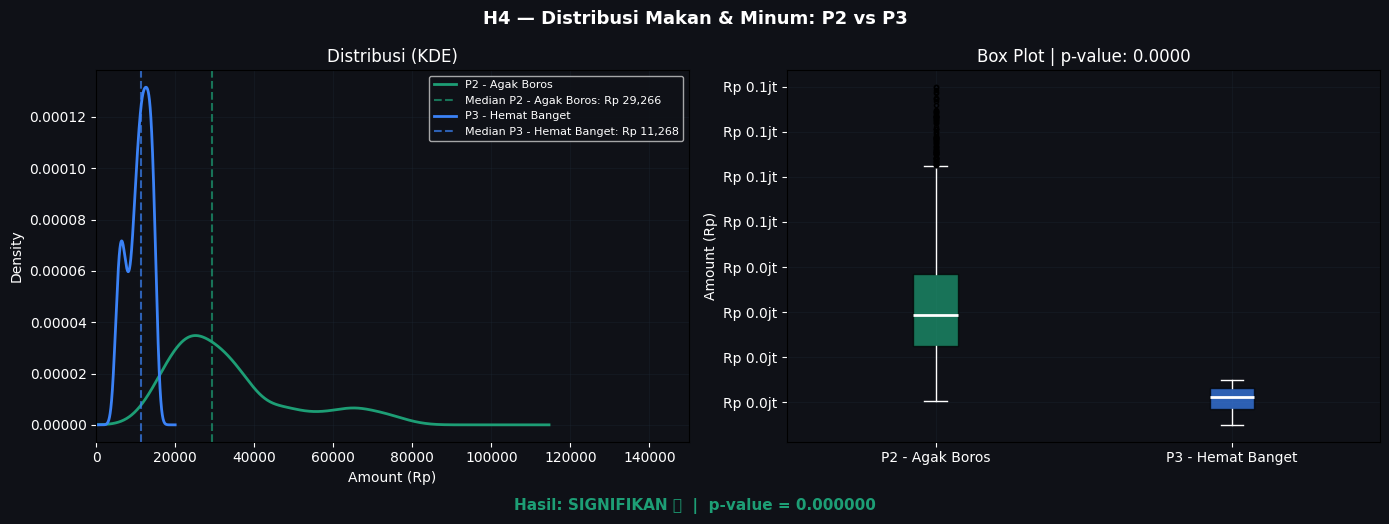

In [10]:
makan_p2 = df_exp[
    (df_exp['Persona'].str.contains('Agak Boros')) &
    (df_exp['Category'] == 'Makan & Minum')
]['Amount'].dropna().values

makan_p3 = df_exp[
    (df_exp['Persona'].str.contains('Hemat Banget')) &
    (df_exp['Category'] == 'Makan & Minum')
]['Amount'].dropna().values

h4 = run_ab_test(makan_p2, makan_p3,
                 'P2 - Agak Boros', 'P3 - Hemat Banget',
                 'H4', 'Makan & Minum: Persona 2 vs Persona 3')

plot_distribution(makan_p2, makan_p3,
                  'P2 - Agak Boros', 'P3 - Hemat Banget',
                  'H4 — Distribusi Makan & Minum: P2 vs P3',
                  h4['p_value'], xlim=150_000)

In [11]:
print('📝 INTERPRETASI H4')
print('-' * 50)
if h4['significant']:
    print(f'Terbukti bahwa pola makan Persona 2 (GoFood, KFC, McDonalds)')
    print(f'secara statistik lebih mahal dari Persona 3 (warteg, kantin).')
    print(f'p={h4["p_value"]:.6f}, effect={h4["effect_label"]} (r={h4["effect_size"]:.3f})')
    print()
    print('💡 Insight: Pilihan tempat makan = faktor paling membedakan')
    print('   pengeluaran antar kelas ekonomi mahasiswa.')
else:
    print(f'Tidak cukup bukti (p={h4["p_value"]:.4f}).')

📝 INTERPRETASI H4
--------------------------------------------------
Terbukti bahwa pola makan Persona 2 (GoFood, KFC, McDonalds)
secara statistik lebih mahal dari Persona 3 (warteg, kantin).
p=0.000000, effect=Besar (r=-0.978)

💡 Insight: Pilihan tempat makan = faktor paling membedakan
   pengeluaran antar kelas ekonomi mahasiswa.


---
## 7. H5 — Pengeluaran Sebelum vs Sesudah Tanggal 15

**H₀:** Tidak ada perbedaan pengeluaran antara awal dan akhir bulan  
**H₁:** Pengeluaran di awal bulan (tgl 1–14) lebih tinggi karena baru terima kiriman

  H5 — Pengeluaran Awal vs Akhir Bulan
  Kelompok A (Tgl 1–14 (Awal Bulan)): n=2,237
    Median : Rp       21,374
    Mean   : Rp       51,801
    Std    : Rp      151,936

  Kelompok B (Tgl 15–31 (Akhir Bulan)): n=2,510
    Median : Rp       19,946
    Mean   : Rp       27,243
    Std    : Rp       26,839

  U-statistic : 2,952,174
  P-value     : 0.002135
  Effect size : r = -0.052 (Kecil)
  Hasil       : ✅ SIGNIFIKAN (α = 0.05)



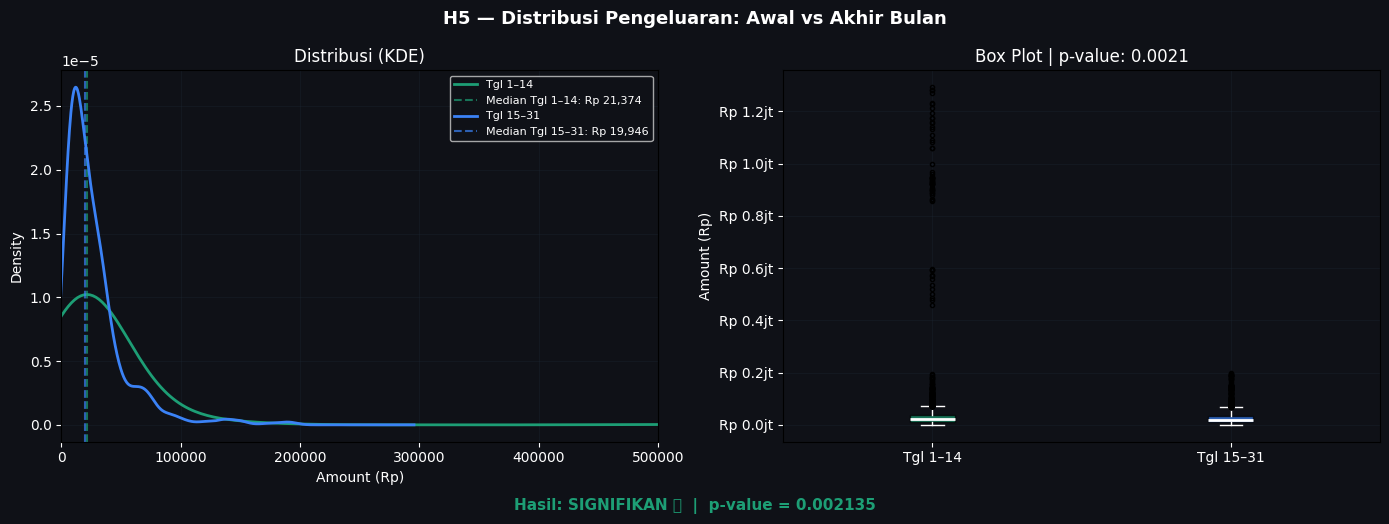

In [12]:
before_15 = df_exp[~df_exp['is_after_15']]['Amount'].dropna().values
after_15  = df_exp[ df_exp['is_after_15']]['Amount'].dropna().values

h5 = run_ab_test(before_15, after_15,
                 'Tgl 1–14 (Awal Bulan)', 'Tgl 15–31 (Akhir Bulan)',
                 'H5', 'Pengeluaran Awal vs Akhir Bulan')

plot_distribution(before_15, after_15,
                  'Tgl 1–14', 'Tgl 15–31',
                  'H5 — Distribusi Pengeluaran: Awal vs Akhir Bulan',
                  h5['p_value'], xlim=500_000)

In [13]:
print('📝 INTERPRETASI H5')
print('-' * 50)
if h5['significant']:
    lebih = 'awal bulan (tgl 1–14)' if h5['median_a'] > h5['median_b'] else 'akhir bulan (tgl 15–31)'
    print(f'Terbukti bahwa pengeluaran lebih tinggi di {lebih}.')
    print(f'p={h5["p_value"]:.6f}')
    print()
    print('💡 Insight: Mahasiswa cenderung lebih bebas belanja')
    print('   di awal bulan setelah menerima kiriman orang tua.')
else:
    print(f'Tidak cukup bukti (p={h5["p_value"]:.4f}).')
    print('💡 Pengeluaran relatif merata sepanjang bulan.')

📝 INTERPRETASI H5
--------------------------------------------------
Terbukti bahwa pengeluaran lebih tinggi di awal bulan (tgl 1–14).
p=0.002135

💡 Insight: Mahasiswa cenderung lebih bebas belanja
   di awal bulan setelah menerima kiriman orang tua.


---
## 8. Ringkasan Semua Hasil A/B Testing

In [14]:
results = [h1, h2, h3, h4, h5]

print('=' * 70)
print('  RINGKASAN HASIL A/B TESTING — BUDGETLY CAPSTONE')
print('=' * 70)
print(f'  {"Hipotesis":<8} {"Kelompok A":<25} {"Kelompok B":<25} {"p-value":<10} {"Hasil"}')
print('-' * 70)

for r in results:
    status = '✅ Signifikan' if r['significant'] else '❌ Tidak'
    print(f'  {r["hypothesis"]:<8} {r["label_a"][:24]:<25} '
          f'{r["label_b"][:24]:<25} {r["p_value"]:<10.4f} {status}')

n_sig = sum(r['significant'] for r in results)
print('=' * 70)
print(f'  {n_sig} dari {len(results)} hipotesis terbukti signifikan (α = {ALPHA})')

  RINGKASAN HASIL A/B TESTING — BUDGETLY CAPSTONE
  Hipotesis Kelompok A                Kelompok B                p-value    Hasil
----------------------------------------------------------------------
  H1       Weekday (Sen–Jum)         Weekend (Sab–Min)         0.1556     ❌ Tidak
  H2       Persona 1 - Si Hemat      Persona 4 - Anak Nongkro  0.0000     ✅ Signifikan
  H3       Awal Semester (Jul, Sep)  Tengah Semester (Mar–Mei  0.0000     ✅ Signifikan
  H4       P2 - Agak Boros           P3 - Hemat Banget         0.0000     ✅ Signifikan
  H5       Tgl 1–14 (Awal Bulan)     Tgl 15–31 (Akhir Bulan)   0.0021     ✅ Signifikan
  4 dari 5 hipotesis terbukti signifikan (α = 0.05)


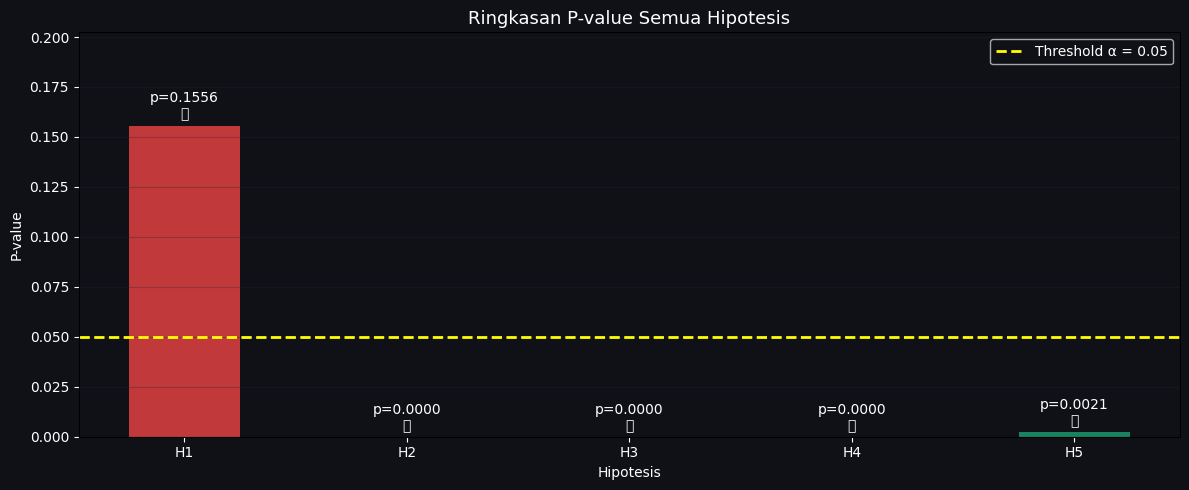

✅ Visualisasi ringkasan tersimpan!


In [15]:
# Visualisasi ringkasan
fig, ax = plt.subplots(figsize=(12, 5))

hyp_labels = [r['hypothesis'] for r in results]
p_values   = [r['p_value'] for r in results]
colors     = [GREEN if r['significant'] else RED for r in results]

bars = ax.bar(hyp_labels, p_values, color=colors, alpha=0.8, width=0.5)
ax.axhline(y=ALPHA, color='yellow', linestyle='--', linewidth=2,
           label=f'Threshold α = {ALPHA}')

for bar, r in zip(bars, results):
    label = f'p={r["p_value"]:.4f}\n{"✅" if r["significant"] else "❌"}'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            label, ha='center', va='bottom', color='white', fontsize=10)

ax.set_title('Ringkasan P-value Semua Hipotesis', color='white', fontsize=13)
ax.set_ylabel('P-value', color='white')
ax.set_xlabel('Hipotesis', color='white')
ax.legend()
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(0, max(p_values) * 1.3)

plt.tight_layout()
os.makedirs('../Dataset/Processed', exist_ok=True)
plt.savefig('../Dataset/Processed/ab_testing_summary.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Visualisasi ringkasan tersimpan!')

In [16]:
# Simpan hasil ke CSV
df_results = pd.DataFrame(results)
df_results.to_csv('../Dataset/Processed/ab_testing_results.csv', index=False)
print('✅ ab_testing_results.csv tersimpan!')
print()
print('Output files:')
print('  📁 Dataset/Processed/ab_testing_results.csv')
print('  📁 Dataset/Processed/ab_testing_summary.png')

✅ ab_testing_results.csv tersimpan!

Output files:
  📁 Dataset/Processed/ab_testing_results.csv
  📁 Dataset/Processed/ab_testing_summary.png
